# Data Diggers:  A Multiview Framework for Fraudulent Review Detection using Deep Embeddings and Stylometric Clustering
### By: Felicia Huffman, Jessica Pamela Feliz Garrido, Elisabeth MacChesney, and Riley Meeves

## Imports

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import numpy as np
import tensorflow as tf
from transformers import AutoTokenizer, AutoModel
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing import sequence
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.neighbors import kneighbors_graph
from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVC
import optuna #Using optuna for the MBO
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import f1_score
from sklearn.metrics import balanced_accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import torch
import torch.nn as nn
from tqdm import tqdm
import umap
import optuna
from sklearn.metrics import adjusted_rand_score
import seaborn as sns

In [35]:
torch.cuda.is_available(), torch.cuda.get_device_name(0)

(True, 'NVIDIA GeForce RTX 4060 Laptop GPU')

In [36]:
import os
os.listdir()

['reviewContent',
 'metadata',
 'reviewGraph',
 '.ipynb_checkpoints',
 'DataDiggersCode_Elisabeth.ipynb',
 'DebertEmbed.csv',
 '.~DataDiggers_FinalProj.ipynb',
 'X_combined.csv']

## Reading & Preparing Data

In [37]:
df_content = pd.read_table("reviewContent", header=None, names=["user_id", "prod_id", "date", "Review"])
df_content.head()

,user_id,prod_id,date,Review
0,923,0,2014-12-08,The food at snack is a selection of popular Gr...
1,924,0,2013-05-16,This little place in Soho is wonderful. I had ...
2,925,0,2013-07-01,ordered lunch for 15 from Snack last Friday. ...
3,926,0,2011-07-28,This is a beautiful quaint little restaurant o...
4,927,0,2010-11-01,Snack is great place for a casual sit down lu...


In [38]:
df_meta = pd.read_table("metadata", header=None, names=["user_id", "prod_id", "rating", "label", "date"])
df_meta.head()

,user_id,prod_id,rating,label,date
0,923,0,3.0,-1,2014-12-08
1,924,0,3.0,-1,2013-05-16
2,925,0,4.0,-1,2013-07-01
3,926,0,4.0,-1,2011-07-28
4,927,0,4.0,-1,2010-11-01


In [39]:
df_labels = pd.read_table("reviewGraph", header=None, names=["ID", "?", "Rating"])
df_labels.head()

,ID,?,Rating
0,923,0,3.0
1,924,0,3.0
2,925,0,4.0
3,926,0,4.0
4,927,0,4.0


### Merging dataframes, Checking for Missing values, and splitting the data

user_id    0
prod_id    0
date       0
Review     0
rating     0
label      0
dtype: int64


Text(0.5, 1.0, 'Class Distribution (%)')

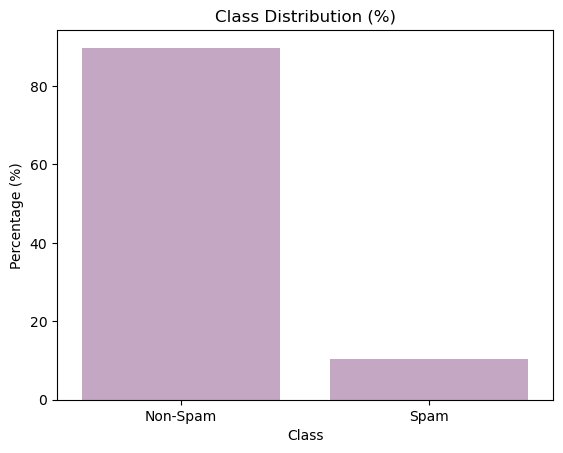

In [40]:
df_all = df_content.merge(
    df_meta,
    on=["user_id", "prod_id", "date"],
    how="left"
)
df_all.head()

print(df_all.isna().sum())
df_95, df_5 = train_test_split(
    df_all,
    test_size=0.01, # CAN ADJUST THIS ID IT DOES NOT RUN
    stratify=df_all["label"],
)

df_5["label_name"] = df_5["label"].map({-1: "Spam", 1: "Non‑Spam"})
pct = df_5["label_name"].value_counts(normalize=True) * 100

sns.barplot(x=pct.index, y=pct.values, color = "#C8A2C8")
plt.ylabel("Percentage (%)")
plt.xlabel("Class")
plt.title("Class Distribution (%)")

#### As we can see, there is a very large class imbalance. This is how it will be in the real world, so making significant improvements to get rid of the bias will not be a good idea, but we will need to threshold tune the models that predict probabilities. 

## DeBerta Embedding

In [41]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


model_name = "microsoft/deberta-v3-base"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)
model = model.to(device)
model.eval()

def get_deberta_embedding(text, batch_size = 500):
    all_embeddings = []

    for i in tqdm(range(0, len(text), batch_size)):
        batch = text[i:i+batch_size]

        inputs = tokenizer(
            batch,
            return_tensors="pt",
            truncation=True,
            padding=True,
            max_length=256
        ).to(device)

        with torch.no_grad():
            outputs = model(**inputs)
            cls_emb = outputs.last_hidden_state[:, 0, :]

        all_embeddings.append(cls_emb.cpu().numpy())

    return np.vstack(all_embeddings)


X_deb = get_deberta_embedding(df_5["Review"].tolist())

df_5["deberta_emb"] = list(X_deb)

df_5.to_csv("DebertEmbed.csv", index=False)

C:\Users\Felic\miniconda3\envs\fish-audio\lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
C:\Users\Felic\miniconda3\envs\fish-audio\lib\site-packages\transformers\convert_slow_tokenizer.py:515: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(
100%|███████████████████████████████████████████████████████████████████████████████████| 8/8 [19:10<00:00, 143.84s/it]


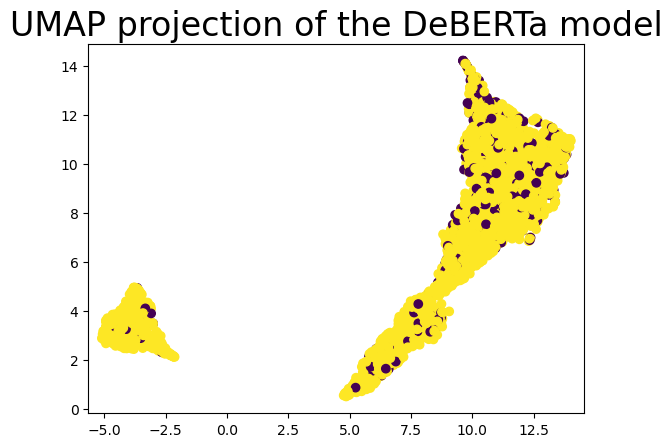

In [42]:
reducer = umap.UMAP()

embedding = reducer.fit_transform(np.vstack(df_5["deberta_emb"].values))
embedding.shape

plt.scatter(
    embedding[:, 0],
    embedding[:, 1],
    c = df_5["label"])
plt.gca().set_aspect('equal', 'datalim')
plt.title('UMAP projection of the DeBERTa model', fontsize=24);
plt.show()

#### Interpretation: 2 clusters, but not clustering according to class. Need to perform further anomoly detection in order for this to be useful.

## CNN Embedding

In [43]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class SimpleTextCNN(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, num_channels=100, kernel_sizes=[3,4,5]):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim)

        self.convs = nn.ModuleList([
            nn.Conv1d(embed_dim, num_channels, k)
            for k in kernel_sizes
        ])

        self.output_dim = num_channels * len(kernel_sizes)

    def forward(self, input_ids):
        x = self.embedding(input_ids)          # (batch, seq_len, embed_dim)
        x = x.permute(0, 2, 1)                 # (batch, embed_dim, seq_len)

        conv_outs = []
        for conv in self.convs:
            c = torch.relu(conv(x))            # (batch, channels, L')
            p = torch.max(c, dim=2).values     # (batch, channels)
            conv_outs.append(p)

        return torch.cat(conv_outs, dim=1)     # (batch, output_dim)


model_name = "microsoft/deberta-v3-base"

tokenizer = AutoTokenizer.from_pretrained(model_name)

cnn = SimpleTextCNN(
    vocab_size=tokenizer.vocab_size,
    embed_dim=128,
    kernel_sizes=[3,4,5],
    num_channels=100
).to(device)

batch_size = 64
all_embeddings = []

for i in tqdm(range(0, len(df_5), batch_size)):
    batch_text = df_5["Review"].iloc[i:i+batch_size].tolist()

    inputs = tokenizer(
        batch_text,
        return_tensors="pt",
        truncation=True,
        padding="max_length",
        max_length=256
    ).to(device)
    input_ids = inputs["input_ids"].to(device)


    with torch.no_grad():
        batch_emb = cnn(inputs["input_ids"])   # (batch, 300)

    all_embeddings.append(batch_emb.cpu().numpy())



cnn_emb = np.vstack(all_embeddings)
df_5["cnn_emb"] = list(cnn_emb)


C:\Users\Felic\miniconda3\envs\fish-audio\lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
C:\Users\Felic\miniconda3\envs\fish-audio\lib\site-packages\transformers\convert_slow_tokenizer.py:515: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(
100%|██████████████████████████████████████████████████████████████████████████████████| 57/57 [00:04<00:00, 13.96it/s]


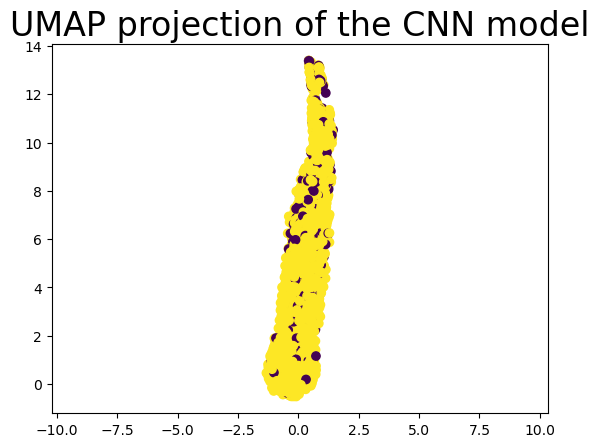

In [44]:
reducer2 = umap.UMAP()

embedding = reducer2.fit_transform(np.vstack(df_5["cnn_emb"].values))
embedding.shape

plt.scatter(
    embedding[:, 0],
    embedding[:, 1],
    c = df_5["label"])
plt.gca().set_aspect('equal', 'datalim')
plt.title('UMAP projection of the CNN model', fontsize=24);
plt.show()

#### This also does not cluster like we want it to, so further anomoly detection should be performed. 

## Feature Extraction

### Creating Several Behavioral features
* time_since_prev: the time that has passed since the previous review by a specific user (normalized)
* time_since_prev_prod: the time that has passed since the previous review of a specific product (normalized)
* user_review_count: Number of reviews user has made
* user_rating_var: how inconsistent each user’s ratings are
* user_avg_rating: The average rating by the user
* user_time_mean: the mean time since the previous review for that user
* user_time_std: deviation of time since the previous review
* user_prod_review_count: number of reviews user has on a product
* user_rating_entropy: how unpredictable user rating is
* prod_rating_var: variance on product rating
* review_len: length of review in char
* word_count: word count
* prod_target_count: number of reviews a product has
* rating_dev: deviation of rating from the mean

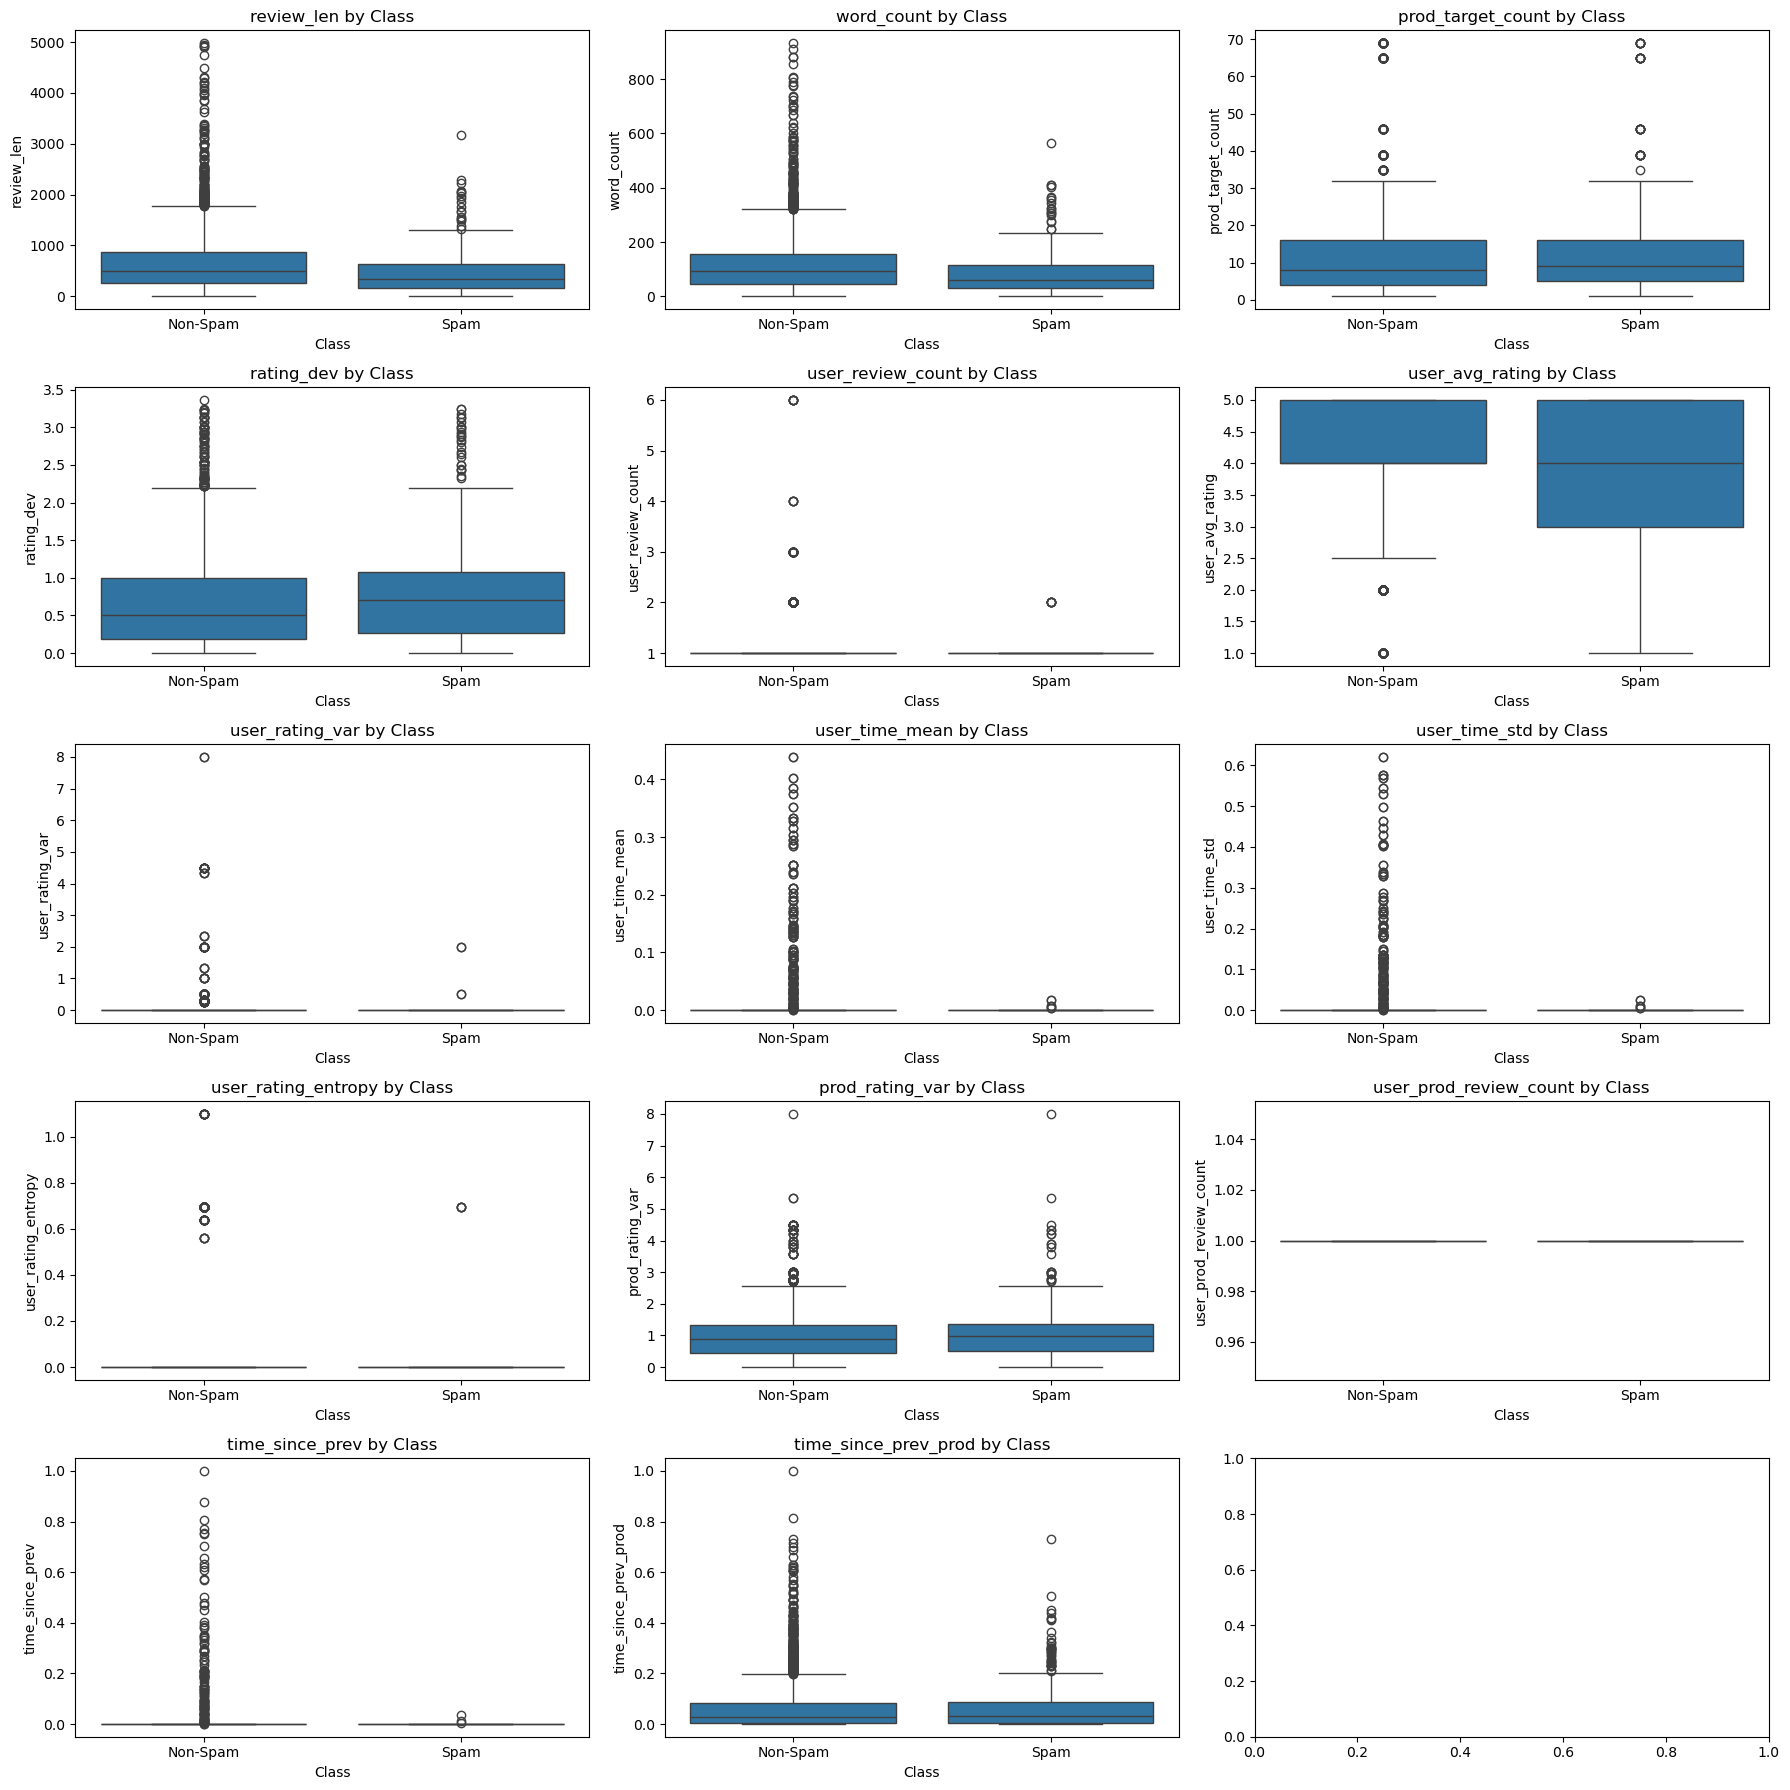

In [50]:
df_5["date"] = pd.to_datetime(df_5["date"])
df_5 = df_5.sort_values(["user_id", "date"])
df_5["time_since_prev"] = (df_5.groupby("user_id")["date"].diff().dt.total_seconds())
df_5["time_since_prev"] = df_5["time_since_prev"].fillna(0)

df_5 = df_5.sort_values(["prod_id", "date"])
df_5["time_since_prev_prod"] = (df_5.groupby("prod_id")["date"].diff().dt.total_seconds())
df_5["time_since_prev_prod"] = df_5["time_since_prev_prod"].fillna(0)

for col in ["time_since_prev", "time_since_prev_prod"]:
    df_5[col] = (df_5[col] - df_5[col].min()) / (df_5[col].max() - df_5[col].min())

X_deb = np.vstack(df_5["deberta_emb"].values)
X_cnn = np.vstack(df_5["cnn_emb"].values)
review_len = df_5["Review"].str.len().to_numpy().reshape(-1, 1)
word_count = df_5["Review"].str.split().str.len().to_numpy().reshape(-1, 1)
timestamp_features = df_5[["time_since_prev", "time_since_prev_prod"]].to_numpy()
prod_means = df_5.groupby('prod_id')['rating'].transform('mean')
rating_dev = np.abs(df_5['rating'] - prod_means).to_numpy().reshape(-1, 1)
prod_target_count = df_5.groupby('prod_id')['Review'].transform('count').to_numpy().reshape(-1, 1)

df_5["review_len"] = df_5["Review"].str.len().to_numpy().reshape(-1, 1)
df_5["word_count"] = df_5["Review"].str.split().str.len().to_numpy().reshape(-1, 1)
df_5["prod_means"] = df_5.groupby('prod_id')['rating'].transform('mean')
df_5["rating_dev"] = np.abs(df_5['rating'] - prod_means).to_numpy().reshape(-1, 1)
df_5["prod_target_count"] = df_5.groupby('prod_id')['Review'].transform('count').to_numpy().reshape(-1, 1)



df_5["user_review_count"] = df_5.groupby("user_id")["Review"].transform("count")
df_5["user_rating_var"] = df_5.groupby("user_id")["rating"].transform("var").fillna(0)
df_5["user_avg_rating"] = df_5.groupby("user_id")["rating"].transform("mean")
df_5["user_time_mean"] = df_5.groupby("user_id")["time_since_prev"].transform("mean")
df_5["user_time_std"] = df_5.groupby("user_id")["time_since_prev"].transform("std").fillna(0)
df_5["user_prod_review_count"] = (
    df_5.groupby(["user_id", "prod_id"])["Review"].transform("count")
)

def entropy(x):
    x = x.astype(int)
    counts = np.bincount(x, minlength=6)[1:]  # ratings 1–5
    probs = counts / counts.sum()
    return -(probs[probs > 0] * np.log(probs[probs > 0])).sum()

df_5["user_rating_entropy"] = (
    df_5.groupby("user_id")["rating"]
        .transform(lambda x: entropy(x.to_numpy()))
)

df_5["prod_rating_var"] = (
    df_5.groupby("prod_id")["rating"]
        .transform("var")
        .fillna(0)
)


X_beh_raw = np.hstack([review_len, word_count, timestamp_features,
                       prod_target_count, rating_dev,
                          df_5[["user_review_count", "user_avg_rating",
                                "user_rating_var","user_time_mean",
                                "user_time_std", "user_rating_entropy",
                                "prod_rating_var", "user_prod_review_count"]].to_numpy()
                      ])
X_beh = StandardScaler().fit_transform(X_beh_raw)

deb_scaler = StandardScaler()
X_deb_std = deb_scaler.fit_transform(X_deb)
from sklearn.decomposition import PCA

pca = PCA(n_components=100)
X_deb_pca = pca.fit_transform(X_deb_std)

X_combined = np.hstack([X_deb_std * 0.3, X_beh * 1])


fig, axes = plt.subplots(5, 3, figsize=(18, 18))
axes = axes.flatten()
features = [
    "review_len",
    "word_count",
    "prod_target_count",
    "rating_dev",
    "user_review_count",
    "user_avg_rating",
    "user_rating_var",
    "user_time_mean",
    "user_time_std",
    "user_rating_entropy",
    "prod_rating_var",
    "user_prod_review_count",
    "time_since_prev",
    "time_since_prev_prod"
]

for ax, feature in zip(axes, features):
    sns.boxplot(
        data=df_5,
        x="label_name",
        y=feature,
        ax=ax
    )
    ax.set_title(f"{feature} by Class", fontsize=12)
    ax.set_xlabel("Class")
    ax.set_ylabel(feature)


plt.tight_layout()
plt.show()

### Combining Embeddings for Clustering: 

In [51]:
W1 = kneighbors_graph(X_deb, n_neighbors=50, mode='connectivity')
W2 = kneighbors_graph(X_beh, n_neighbors=50, mode='connectivity')
W3 = kneighbors_graph(X_cnn, n_neighbors=50, mode='connectivity')

deg1 = W1.sum() / W1.shape[0]
deg2 = W2.sum() / W2.shape[0]
deg3 = W3.sum() / W3.shape[0]

w1_wgt = 1 / deg1
w2_wgt = 1 / deg2
w3_wgt = 1 / deg3
sum = w1_wgt + w2_wgt + w3_wgt
w1_wgt, w2_wgt, w3_wgt = w1_wgt/sum, w2_wgt/sum, w3_wgt/sum

W_fused = w1_wgt*W1 + w2_wgt*W2 + w3_wgt*W3

# Modeling

## Multiview Specteral Clustering

C:\Users\Felic\miniconda3\envs\fish-audio\lib\site-packages\sklearn\manifold\_spectral_embedding.py:309: UserWarning: Array is not symmetric, and will be converted to symmetric by average with its transpose.
  adjacency = check_symmetric(adjacency)


ARI: -0.013379755914872003
NMI: 0.008384647177976826


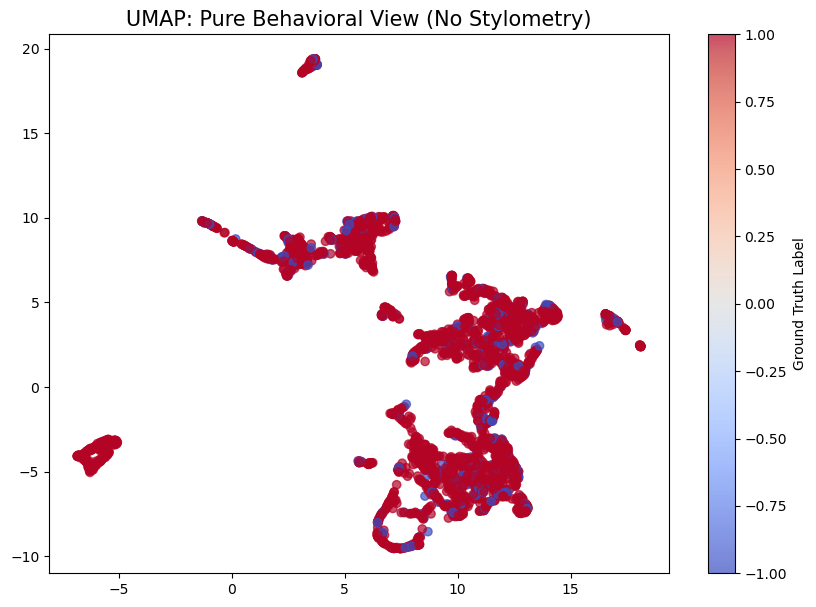

In [52]:
from sklearn.cluster import SpectralClustering

sc = SpectralClustering(
    n_clusters=2,
    affinity='precomputed',
    assign_labels='cluster_qr'
)

df_5["labels_msc"]= sc.fit_predict(W_fused)

from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

ari = adjusted_rand_score(df_5["label"], df_5["labels_msc"])
nmi = normalized_mutual_info_score(df_5["label"], df_5["labels_msc"])

print("ARI:", ari)
print("NMI:", nmi)

reducer = umap.UMAP()
embedding = reducer.fit_transform(X_beh)

plt.figure(figsize=(10, 7))
plt.scatter(embedding[:, 0], embedding[:, 1], c=df_5["label"], cmap='coolwarm', alpha=0.7)
plt.title('UMAP: Pure Behavioral View (No Stylometry)', fontsize=15)
plt.colorbar(label='Ground Truth Label')
plt.show()

In [55]:
def objective(trial):
    # 1. Suggest weights for the three views (must sum to 1.0)
    w1 = trial.suggest_float("w1", 0.1, 0.8)
    w2 = trial.suggest_float("w2", 0.1, 0.8)
    w3 = trial.suggest_float("w3", 0.1, 0.8)

    # Normalize weights so they sum to 1
    total = w1 + w2 + w3
    w1, w2, w3 = w1/total, w2/total, w3/total

    # 2. Fuse the graphs with these trial weights
    W_fused_trial = (w1 * W1) + (w2 * W2) + (w3 * W3)

    # 3. Run Spectral Clustering
    # Note: We use a fixed random_state to ensure consistency
    sc_trial = SpectralClustering(
        n_clusters=2,
        affinity='precomputed',
        assign_labels='kmeans',
        random_state=42
    )

    try:
        labels = sc_trial.fit_predict(W_fused_trial)
        # 4. Objective: Maximize ARI (how well we match ground truth)
        score = adjusted_rand_score(df_5["label"], labels)
    except:
        score = 0 # Handle cases where clustering fails to converge

    return score

# Create the study and optimize
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=10) # Increase n_trials for better results

print("\n--- OPTUNA MBO RESULTS ---")
print(f"Best ARI Score: {study.best_value:.4f}")
print(f"Best Weights: {study.best_params}")



[I 2026-04-11 19:48:33,472] A new study created in memory with name: no-name-39b1be80-b639-43c5-bf0f-7b41530824f4
C:\Users\Felic\miniconda3\envs\fish-audio\lib\site-packages\sklearn\manifold\_spectral_embedding.py:309: UserWarning: Array is not symmetric, and will be converted to symmetric by average with its transpose.
  adjacency = check_symmetric(adjacency)
[I 2026-04-11 19:48:49,221] Trial 0 finished with value: -0.017125396033512798 and parameters: {'w1': 0.5252100601814016, 'w2': 0.6312795806520176, 'w3': 0.7798779534677848}. Best is trial 0 with value: -0.017125396033512798.
C:\Users\Felic\miniconda3\envs\fish-audio\lib\site-packages\sklearn\manifold\_spectral_embedding.py:309: UserWarning: Array is not symmetric, and will be converted to symmetric by average with its transpose.
  adjacency = check_symmetric(adjacency)
[I 2026-04-11 19:49:04,423] Trial 1 finished with value: -0.02865547012217742 and parameters: {'w1': 0.24722182413611615, 'w2': 0.39071499874736026, 'w3': 0.12829


--- OPTUNA MBO RESULTS ---
Best ARI Score: -0.0104
Best Weights: {'w1': 0.17222358309877642, 'w2': 0.2958654023759425, 'w3': 0.5575831336998026}


In [57]:
# Apply the best weights to your final labels
best_w = study.best_params
w_sum = sum(best_w.values())
W_optimized = (best_w['w1']/w_sum * W1) + (best_w['w2']/w_sum * W2) + (best_w['w3']/w_sum * W3)

df_5['mbo_labels'] = SpectralClustering(
    n_clusters=2, affinity='precomputed', assign_labels='kmeans', random_state=42
).fit_predict(W_optimized)

pd.crosstab(df_5['label_name'], df_5['mbo_labels'])

C:\Users\Felic\miniconda3\envs\fish-audio\lib\site-packages\sklearn\manifold\_spectral_embedding.py:309: UserWarning: Array is not symmetric, and will be converted to symmetric by average with its transpose.
  adjacency = check_symmetric(adjacency)


mbo_labels,0,1
label_name,,
Non‑Spam,1419,1802
Spam,107,262


##### As you can see, this was not very effective since the classes seem to be evenly distributed, it is random

## Classification Models

In [59]:
df_export = pd.DataFrame(X_combined)
df_export.to_csv("X_combined.csv", index=False)

In [60]:
X = X_combined
y = df_5["label"].values

df_5["label_fixed"] = df_5["label"].replace({-1: 0, 1: 1})

X_train, X_val, y_train, y_val = train_test_split(
    X_combined,
    df_5["label_fixed"],
    test_size=0.2,
    stratify=df_5["label_fixed"]
)

## XGBoost

In [61]:
pos = np.sum(y_train == 1)
neg = np.sum(y_train == 0)
spw = neg / pos

def objective(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 800),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "scale_pos_weight": spw,
        "eval_metric": "auc",
        "tree_method": "hist"
    }

    model = XGBClassifier(**params)

    model.fit(X_train, y_train)

    pred_proba = model.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, pred_proba)

    return auc

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=10)

print("Best AUC:", study.best_value)
print("Best Params:", study.best_params)

[I 2026-04-11 19:53:03,901] A new study created in memory with name: no-name-a2b57626-ff7b-4b17-81de-8df83c892c23
[I 2026-04-11 19:53:07,310] Trial 0 finished with value: 0.6408007386268255 and parameters: {'n_estimators': 318, 'max_depth': 10, 'learning_rate': 0.22642291495526445, 'subsample': 0.9660376266315203, 'colsample_bytree': 0.5590011165660704, 'min_child_weight': 6, 'gamma': 2.1980826979616097}. Best is trial 0 with value: 0.6408007386268255.
[I 2026-04-11 19:53:12,741] Trial 1 finished with value: 0.6704926976666107 and parameters: {'n_estimators': 340, 'max_depth': 5, 'learning_rate': 0.01464229052192122, 'subsample': 0.7360971432392178, 'colsample_bytree': 0.660406914088691, 'min_child_weight': 5, 'gamma': 4.951683362757503}. Best is trial 1 with value: 0.6704926976666107.
[I 2026-04-11 19:53:27,896] Trial 2 finished with value: 0.6627287225113312 and parameters: {'n_estimators': 411, 'max_depth': 6, 'learning_rate': 0.0318861962069188, 'subsample': 0.6174004990314954, 'co

Best AUC: 0.6704926976666107
Best Params: {'n_estimators': 340, 'max_depth': 5, 'learning_rate': 0.01464229052192122, 'subsample': 0.7360971432392178, 'colsample_bytree': 0.660406914088691, 'min_child_weight': 5, 'gamma': 4.951683362757503}


In [62]:
best = study.best_params

xgb = XGBClassifier(
    n_estimators=best["n_estimators"],
    max_depth=best["max_depth"],
    learning_rate=best["learning_rate"],
    subsample=best["subsample"],
    colsample_bytree=best["colsample_bytree"],
    min_child_weight = best["min_child_weight"],
    gamma = best["gamma"],
    scale_pos_weight=spw,
    eval_metric="auc",
    tree_method="hist"
)

xgb.fit(X_train, y_train)

pred_proba = xgb.predict_proba(X_val)[:, 1]

thresholds = np.linspace(0.01, 0.99, 200)
balacc_xg = [balanced_accuracy_score(y_val, pred_proba >= t) for t in thresholds]

best_threshold = thresholds[np.argmax(balacc_xg)]

pred = (pred_proba >= best_threshold).astype(int)

xgb_auc = roc_auc_score(y_val, pred_proba)
xgb_f1 = f1_score(y_val, pred)
xgb_acc = accuracy_score(y_val, pred)
xgb_balacc = balanced_accuracy_score(y_val, pred)

xgb_test_results = {
    "Accuracy": xgb_acc,
    "Balanced Accuracy": xgb_balacc,
    "F1 Score": xgb_f1,
    "ROC AUC": xgb_auc
}

print("XGBOOST")
print("Best threshold (F1):", best_threshold)
print("AUC:", xgb_auc)
print("F1:", xgb_f1)
print("Accuracy:", xgb_acc)

XGBOOST
Best threshold (F1): 0.6206532663316583
AUC: 0.6704926976666107
F1: 0.646878198567042
Accuracy: 0.5194986072423399


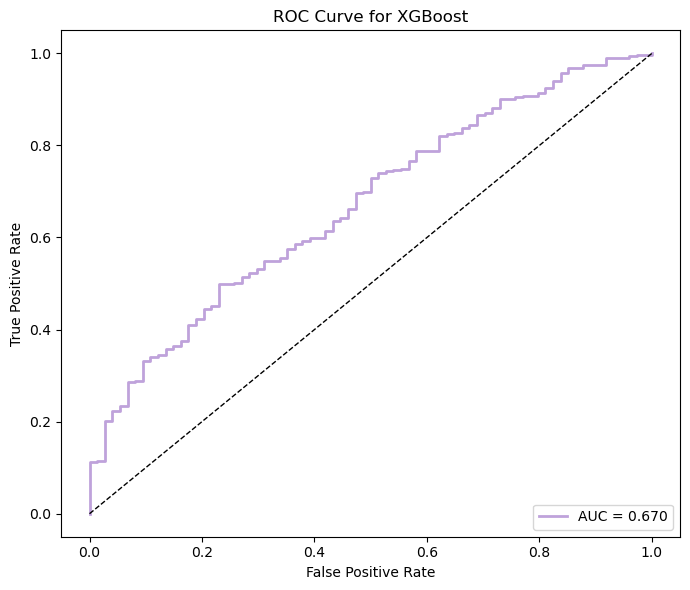

In [64]:
from sklearn.metrics import roc_curve, auc

# Compute ROC
fpr, tpr, thresholds = roc_curve(y_val, pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color="#BFA2DB", lw=2, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], "k--", lw=1)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for XGBoost")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## Logistic Regression



In [65]:
def objective(trial):

    C = trial.suggest_float("C", 1e-4, 10.0, log=True)
    penalty = trial.suggest_categorical("penalty", ["l1", "l2"])
    solver = "liblinear" if penalty == "l1" else trial.suggest_categorical("solver", ["liblinear", "saga"])
    class_weight = trial.suggest_categorical("class_weight", [None, "balanced"])

    LR = LogisticRegression(
        C=C,
        penalty=penalty,
        solver=solver,
        class_weight=class_weight,
        max_iter=2000
    )

    LR.fit(X_train, y_train)

    preds = LR.predict_proba(X_val)[:, 1]
    preds_raw = LR.predict(X_val)

    score = roc_auc_score(y_val, preds)


    return score

study_LR = optuna.create_study(direction="maximize")
study_LR.optimize(objective, n_trials=10)

print("Best Score:", study_LR.best_value)
print("Best Params:", study_LR.best_params)

[I 2026-04-11 19:56:18,579] A new study created in memory with name: no-name-5a6d7a22-f918-4451-bb84-db2af1dea0e5
[I 2026-04-11 19:57:47,449] Trial 0 finished with value: 0.6484807789155616 and parameters: {'C': 1.9543119858406763, 'penalty': 'l2', 'solver': 'saga', 'class_weight': 'balanced'}. Best is trial 0 with value: 0.6484807789155616.
[I 2026-04-11 19:57:50,020] Trial 1 finished with value: 0.6988207151250629 and parameters: {'C': 0.016955584524926355, 'penalty': 'l2', 'solver': 'saga', 'class_weight': 'balanced'}. Best is trial 1 with value: 0.6988207151250629.
[I 2026-04-11 19:57:50,685] Trial 2 finished with value: 0.698610877958704 and parameters: {'C': 0.01717146245006797, 'penalty': 'l2', 'solver': 'liblinear', 'class_weight': 'balanced'}. Best is trial 1 with value: 0.6988207151250629.
[I 2026-04-11 19:57:50,812] Trial 3 finished with value: 0.5 and parameters: {'C': 0.00015021403380793854, 'penalty': 'l1', 'class_weight': None}. Best is trial 1 with value: 0.698820715125

Best Score: 0.7009610542219238
Best Params: {'C': 0.17057715259632483, 'penalty': 'l1', 'class_weight': None}


In [66]:

best_LR = study_LR.best_params

final_model = LogisticRegression(
    C=best_LR["C"],
    penalty=best_LR["penalty"],
    solver="liblinear" if best_LR["penalty"] == "l1" else best_LR["solver"],
    class_weight=best_LR["class_weight"],
    max_iter=2000,
    random_state=42
)

final_model.fit(X_train, y_train)

pred_proba_LR = final_model.predict_proba(X_val)[:, 1]

thresholds_LR = np.linspace(0.01, 0.99, 200)
balacc_LR = [balanced_accuracy_score(y_val, pred_proba_LR >= t) for t in thresholds]

best_threshold_LR = thresholds[np.argmax(balacc_LR)]

preds_raw_LR = (pred_proba_LR >= best_threshold_LR).astype(int)


In [67]:
lr_roc = roc_auc_score(y_val, pred_proba_LR)
lr_f1 = f1_score(y_val, preds_raw_LR)
lr_accuracy = accuracy_score(y_val, preds_raw_LR)
lr_balanced_acc = balanced_accuracy_score(y_val, preds_raw_LR)

lr_test_results = {
    "Accuracy": lr_accuracy,
    "Balanced Accuracy": lr_balanced_acc,
    "F1 Score": lr_f1,
    "ROC AUC": lr_roc
}

print("Logistic Regression")
print("Best Threshold:", best_threshold)
print("ROC/AUC Score:", lr_roc)
print("F1 Score:", lr_f1)
print("Accuracy:", lr_accuracy)

Logistic Regression
Best Threshold: 0.6206532663316583
ROC/AUC Score: 0.700940070505288
F1 Score: 0.9177555726364335
Accuracy: 0.850974930362117


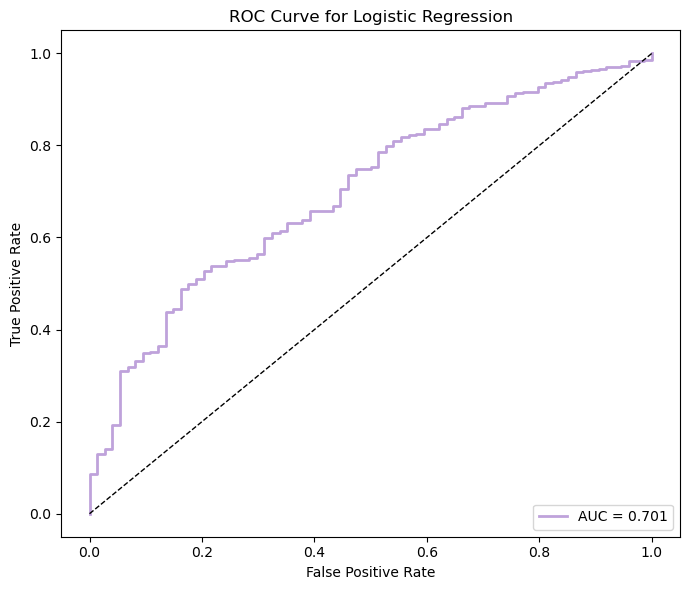

In [68]:
# Compute ROC
fpr, tpr, thresholds = roc_curve(y_val, pred_proba_LR)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color="#BFA2DB", lw=2, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], "k--", lw=1)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Logistic Regression")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## SVM

In [69]:
from sklearn.decomposition import PCA

pca = PCA(n_components=100)
X_train_pca = pca.fit_transform(X_train)
X_val_pca = pca.transform(X_val)

def objective(trial):
    kernel = trial.suggest_categorical("kernel", ["rbf", "poly"])
    C = trial.suggest_float("C", 1e-4, 10.0, log=True)
    if kernel == "rbf":
        gamma = trial.suggest_float("gamma", 1e-5, 1e-1, log=True)
        degree = trial.suggest_int("degree", 1, 10)
        coef0 = 0.0

    elif kernel == "poly":
        degree = trial.suggest_int("degree", 2, 5)
        gamma = trial.suggest_float("gamma", 1e-5, 1e-1, log=True)
        coef0 = trial.suggest_float("coef0", 0.0, 1.0)

    class_weight = trial.suggest_categorical("class_weight", [None, "balanced"])


    # Build model
    sv = SVC(
        kernel = kernel,
        degree = degree,
        gamma = gamma,
        C=C,
        class_weight=class_weight,
        probability = True,
        max_iter=20000,
    )

    sv.fit(X_train_pca, y_train)

    sv_preds = sv.predict_proba(X_val_pca)[:, 1]

    score = roc_auc_score(y_val, sv_preds)


    return score

study_sv = optuna.create_study(direction="maximize")
study_sv.optimize(objective, n_trials=10)

print("Best Score:", study_sv.best_value)
print("Best Params:", study_sv.best_params)

[I 2026-04-11 19:58:35,005] A new study created in memory with name: no-name-85a9d6dd-d9b3-4893-bda1-f9f7af4be3d3
[I 2026-04-11 19:58:37,298] Trial 0 finished with value: 0.6490263555480946 and parameters: {'kernel': 'rbf', 'C': 0.003147317185992864, 'gamma': 4.623539672135575e-05, 'degree': 6, 'class_weight': None}. Best is trial 0 with value: 0.6490263555480946.
[I 2026-04-11 19:58:44,549] Trial 1 finished with value: 0.3586536847406412 and parameters: {'kernel': 'poly', 'C': 0.006333414289697665, 'degree': 5, 'gamma': 0.001201738372615275, 'coef0': 0.5686481689177875, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.6490263555480946.
[I 2026-04-11 19:58:45,920] Trial 2 finished with value: 0.5910273627664931 and parameters: {'kernel': 'poly', 'C': 0.7077107473276149, 'degree': 2, 'gamma': 0.0002797886825807295, 'coef0': 0.5011741645649094, 'class_weight': None}. Best is trial 0 with value: 0.6490263555480946.
[I 2026-04-11 19:58:47,807] Trial 3 finished with value: 0.61759

Best Score: 0.6636100386100386
Best Params: {'kernel': 'poly', 'C': 0.08186616076146783, 'degree': 3, 'gamma': 0.011144716797864886, 'coef0': 0.4990173880342099, 'class_weight': 'balanced'}


In [70]:
best_sv = study_sv.best_params

SVC_model = SVC(
    kernel = best_sv["kernel"],
    degree = best_sv["degree"],
    gamma = best_sv["gamma"],
    C=best_sv["C"],
    class_weight=best_sv["class_weight"],
    probability = True,
    max_iter=2000,
)

SVC_model.fit(X_train_pca, y_train)
pred_proba_sv = SVC_model.predict_proba(X_val_pca)[:, 1]
 
thresholds = np.linspace(0.01, 0.99, 200)
balacc_sv = [balanced_accuracy_score(y_val, pred_proba_sv >= t) for t in thresholds]

best_threshold_sv = thresholds[np.argmax(balacc_sv)]

sv_preds_raw = (pred_proba_sv >= best_threshold_sv).astype(int)

C:\Users\Felic\miniconda3\envs\fish-audio\lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


#### Note: with class imbalance, only truly want to optimize auc/roc score

In [71]:
svm_roc = roc_auc_score(y_val, pred_proba_sv)
svm_f1 = f1_score(y_val, sv_preds_raw)
svm_accuracy = accuracy_score(y_val, sv_preds_raw)
svm_balanced_acc = balanced_accuracy_score(y_val, sv_preds_raw)

svm_test_results = {
    "Accuracy": svm_accuracy,
    "Balanced Accuracy": svm_balanced_acc,
    "F1 Score": svm_f1,
    "ROC AUC": svm_roc
}

print("SVM")
print("Best Threshold:", best_threshold_sv)
print("ROC/AUC Score:", svm_roc)
print("F1 Score:", svm_f1)
print("Accuracy:", svm_accuracy)


SVM
Best Threshold: 0.8915075376884423
ROC/AUC Score: 0.5406664428403558
F1 Score: 0.03358778625954199
Accuracy: 0.11838440111420613


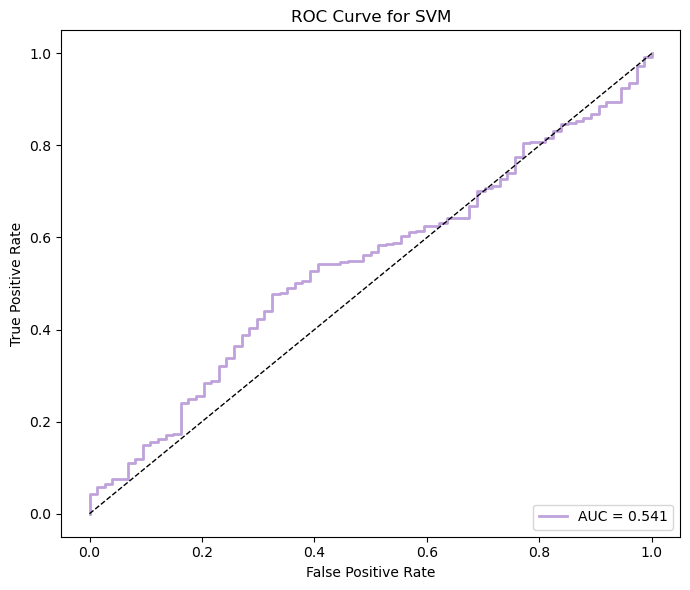

In [72]:
# Compute ROC
fpr, tpr, thresholds = roc_curve(y_val, pred_proba_sv)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color="#BFA2DB", lw=2, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], "k--", lw=1)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for SVM")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## Neural Network

In [73]:
from sklearn.decomposition import PCA
from sklearn.neural_network import MLPClassifier

pca = PCA(n_components=100)
X_train_pca = pca.fit_transform(X_train)
X_val_pca = pca.transform(X_val)

def objective(trial):
    n_layers = trial.suggest_int("n_layers", 1, 3)
    hidden_layer_sizes = tuple(trial.suggest_int(f"n_units_layer_{i}", 32, 256) for i in range(n_layers))
    activation = trial.suggest_categorical("activation", ["relu", "tanh"])
    solver = trial.suggest_categorical("solver", ["adam", "lbfgs"])
    alpha=trial.suggest_float("alpha", 1e-6, 1e-2, log=True)
    learning_rate= trial.suggest_categorical("learning_rate", ["constant", "adaptive"])
    learning_rate_init = trial.suggest_float("learning_rate_init", 1e-4, 1e-2, log=True)

    # Build model
    model = MLPClassifier(
        hidden_layer_sizes = hidden_layer_sizes,
        activation = activation,
        solver = solver,
        alpha=alpha,
        learning_rate=learning_rate,
        learning_rate_init=learning_rate_init,
        max_iter=50000
    )

    model.fit(X_train_pca, y_train)

    preds = model.predict_proba(X_val_pca)[:, 1]

    score = roc_auc_score(y_val, preds)


    return score

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=10)

print("Best Score:", study.best_value)
print("Best Params:", study.best_params)

[I 2026-04-11 19:59:52,386] A new study created in memory with name: no-name-d0613154-9308-418b-9f92-e1e4000a9090
[I 2026-04-11 19:59:56,189] Trial 0 finished with value: 0.5629196743327177 and parameters: {'n_layers': 1, 'n_units_layer_0': 112, 'activation': 'tanh', 'solver': 'lbfgs', 'alpha': 0.001746516376555532, 'learning_rate': 'adaptive', 'learning_rate_init': 0.0005844793405208487}. Best is trial 0 with value: 0.5629196743327177.
[I 2026-04-11 20:01:05,338] Trial 1 finished with value: 0.6640506966593923 and parameters: {'n_layers': 1, 'n_units_layer_0': 109, 'activation': 'tanh', 'solver': 'adam', 'alpha': 0.0026612496512547945, 'learning_rate': 'adaptive', 'learning_rate_init': 0.000165226318533908}. Best is trial 1 with value: 0.6640506966593923.
[I 2026-04-11 20:01:12,198] Trial 2 finished with value: 0.5315385261037435 and parameters: {'n_layers': 2, 'n_units_layer_0': 125, 'n_units_layer_1': 203, 'activation': 'relu', 'solver': 'lbfgs', 'alpha': 5.151536080445089e-06, 'lea

Best Score: 0.6640506966593923
Best Params: {'n_layers': 1, 'n_units_layer_0': 109, 'activation': 'tanh', 'solver': 'adam', 'alpha': 0.0026612496512547945, 'learning_rate': 'adaptive', 'learning_rate_init': 0.000165226318533908}


In [74]:
best_nn = study.best_params

nn_model = MLPClassifier(
    hidden_layer_sizes = tuple(best_nn[f"n_units_layer_{i}"] for i in range(best_nn["n_layers"])),
    activation = best_nn["activation"],
    solver = best_nn["solver"],
    alpha=best_nn["alpha"],
    learning_rate=best_nn["learning_rate"],
    learning_rate_init=best_nn["learning_rate_init"],
    max_iter=50000
)

nn_model.fit(X_train_pca, y_train)
pred_proba_nn = nn_model.predict_proba(X_val_pca)[:, 1]

thresholds = np.linspace(0.01, 0.99, 200)
balacc_nn = [balanced_accuracy_score(y_val, pred_proba_nn >= t) for t in thresholds]

best_threshold = thresholds[np.argmax(balacc_nn)]

preds_raw_nn = (pred_proba_nn >= best_threshold).astype(int)

In [75]:
nn_roc = roc_auc_score(y_val, pred_proba_nn)
nn_f1 = f1_score(y_val, preds_raw_nn)
nn_accuracy = accuracy_score(y_val, preds_raw_nn)
nn_balanced_acc = balanced_accuracy_score(y_val, preds_raw_nn)

nn_test_results = {
    "Accuracy": nn_accuracy,
    "Balanced Accuracy": nn_balanced_acc,
    "F1 Score": nn_f1,
    "ROC AUC": nn_roc
}

print("NN Classifier")
print("Best Threshold:", best_threshold)
print("ROC/AUC Score:", nn_roc)
print("F1 Score:", nn_f1)
print("Accuracy:", nn_accuracy)

MLP Classifier
Best Threshold: 0.99
ROC/AUC Score: 0.604100218230653
F1 Score: 0.708253358925144
Accuracy: 0.5766016713091922


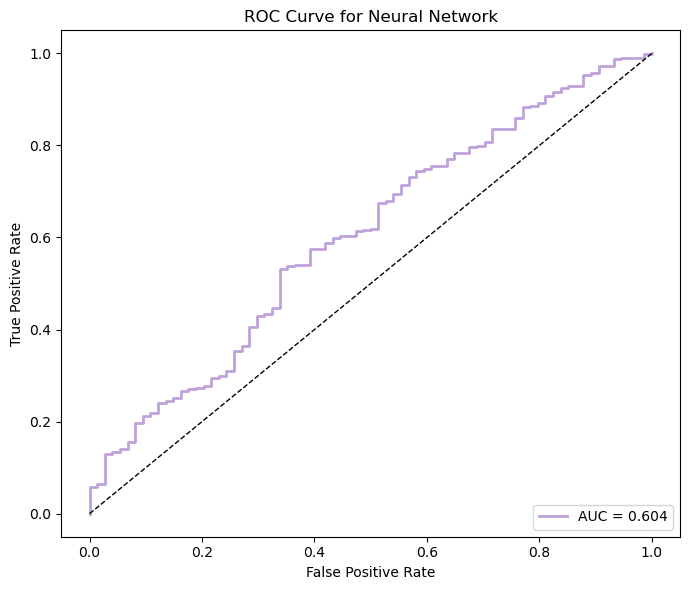

In [76]:
# Compute ROC
fpr, tpr, thresholds = roc_curve(y_val, pred_proba_nn)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color="#BFA2DB", lw=2, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], "k--", lw=1)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Neural Network")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## Decision Tree

In [77]:
def objective(trial):
    params = {
        "criterion": trial.suggest_categorical("criterion", ["gini", "entropy"]),
        "max_depth": trial.suggest_int("max_depth", 3, 15),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical("max_features", [None, "sqrt", "log2"]),
        "class_weight": trial.suggest_categorical("class_weight", [None, "balanced"]),
    }

    model = DecisionTreeClassifier(**params, random_state=42)
    model.fit(X_train, y_train)

    pred_proba = model.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, pred_proba)
    return auc

study_DT = optuna.create_study(direction="maximize")
study_DT.optimize(objective, n_trials=10)

print("Best AUC:", study_DT.best_value)
print("Best Params:", study_DT.best_params)

[I 2026-04-11 20:03:52,411] A new study created in memory with name: no-name-a231849b-7531-46f8-a7c4-ec6b04ff69f6
[I 2026-04-11 20:03:57,876] Trial 0 finished with value: 0.5191476414302503 and parameters: {'criterion': 'gini', 'max_depth': 9, 'min_samples_split': 3, 'min_samples_leaf': 9, 'max_features': None, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.5191476414302503.
[I 2026-04-11 20:03:57,961] Trial 1 finished with value: 0.5421877622964579 and parameters: {'criterion': 'gini', 'max_depth': 8, 'min_samples_split': 7, 'min_samples_leaf': 10, 'max_features': 'log2', 'class_weight': 'balanced'}. Best is trial 1 with value: 0.5421877622964579.
[I 2026-04-11 20:04:06,046] Trial 2 finished with value: 0.5521969951317778 and parameters: {'criterion': 'entropy', 'max_depth': 13, 'min_samples_split': 15, 'min_samples_leaf': 10, 'max_features': None, 'class_weight': None}. Best is trial 2 with value: 0.5521969951317778.
[I 2026-04-11 20:04:06,342] Trial 3 finished with value

Best AUC: 0.6142773207990598
Best Params: {'criterion': 'entropy', 'max_depth': 6, 'min_samples_split': 4, 'min_samples_leaf': 10, 'max_features': 'log2', 'class_weight': 'balanced'}


In [78]:
best_dt_params = study_DT.best_params

dt_model = DecisionTreeClassifier(
    criterion=best_dt_params["criterion"],
    max_depth=best_dt_params["max_depth"],
    min_samples_split=best_dt_params["min_samples_split"],
    min_samples_leaf=best_dt_params["min_samples_leaf"],
    max_features=best_dt_params["max_features"],
    class_weight=best_dt_params["class_weight"],
)

dt_model.fit(X_train, y_train)
pred_proba = dt_model.predict_proba(X_val)[:, 1]

thresholds = np.linspace(0.01, 0.99, 200)
balacc = [balanced_accuracy_score(y_val, pred_proba >= t) for t in thresholds]

best_threshold = thresholds[np.argmax(balacc)]

preds_raw = (pred_proba >= best_threshold).astype(int)

In [79]:
dt_roc = roc_auc_score(y_val, pred_proba)
dt_f1 = f1_score(y_val, preds_raw)
dt_accuracy = accuracy_score(y_val, preds_raw)
dt_balanced_acc = balanced_accuracy_score(y_val, preds_raw)

dt_test_results = {
    "Accuracy": dt_accuracy,
    "Balanced Accuracy": dt_balanced_acc,
    "F1 Score": dt_f1,
    "ROC AUC": dt_roc
}

print("Decision Tree")
print("Best Threshold:", best_threshold)
print("ROC/AUC Score:", dt_roc)
print("F1 Score:", dt_f1)
print("Accuracy:", dt_accuracy)

Decision Tree
Best Threshold: 0.5615577889447236
ROC/AUC Score: 0.5230296290078899
F1 Score: 0.6506986027944112
Accuracy: 0.5125348189415042


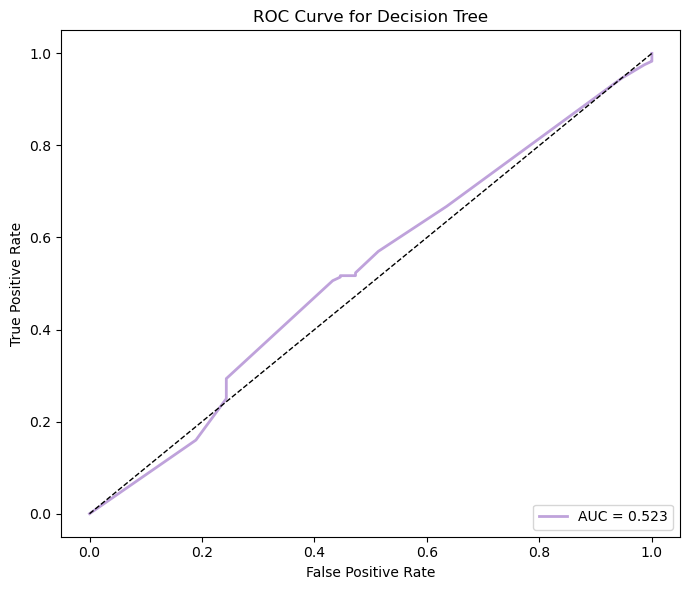

In [80]:
# Compute ROC
fpr, tpr, thresholds = roc_curve(y_val, pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color="#BFA2DB", lw=2, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], "k--", lw=1)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Decision Tree")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## Random Forest

In [81]:
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 600),
        "max_depth": trial.suggest_int("max_depth", 3, 15),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2"]),
        "class_weight": trial.suggest_categorical("class_weight", [None, "balanced"]),
    }

    model = RandomForestClassifier(**params, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)

    pred_proba = model.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, pred_proba)
    return auc

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=10)

print("Best AUC:", study.best_value)
print("Best Params:", study.best_params)

[I 2026-04-11 20:05:11,660] A new study created in memory with name: no-name-62519871-8608-4456-a939-4e6a04d1c574
[I 2026-04-11 20:05:14,796] Trial 0 finished with value: 0.6553634379721336 and parameters: {'n_estimators': 364, 'max_depth': 12, 'min_samples_split': 4, 'min_samples_leaf': 4, 'max_features': 'log2', 'class_weight': 'balanced'}. Best is trial 0 with value: 0.6553634379721336.
[I 2026-04-11 20:05:19,372] Trial 1 finished with value: 0.6582801745845224 and parameters: {'n_estimators': 208, 'max_depth': 13, 'min_samples_split': 2, 'min_samples_leaf': 9, 'max_features': 'sqrt', 'class_weight': None}. Best is trial 1 with value: 0.6582801745845224.
[I 2026-04-11 20:05:21,028] Trial 2 finished with value: 0.6388282692630518 and parameters: {'n_estimators': 224, 'max_depth': 8, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'class_weight': 'balanced'}. Best is trial 1 with value: 0.6582801745845224.
[I 2026-04-11 20:05:24,174] Trial 3 finished with value:

Best AUC: 0.6773333892899109
Best Params: {'n_estimators': 478, 'max_depth': 8, 'min_samples_split': 14, 'min_samples_leaf': 9, 'max_features': 'sqrt', 'class_weight': None}


In [82]:
best_rf_params = study.best_params

rf_model = RandomForestClassifier(
    n_estimators=best_rf_params["n_estimators"],
    max_depth=best_rf_params["max_depth"],
    min_samples_split=best_rf_params["min_samples_split"],
    min_samples_leaf=best_rf_params["min_samples_leaf"],
    max_features=best_rf_params["max_features"],
    class_weight=best_rf_params["class_weight"],
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
pred_proba = rf_model.predict_proba(X_val)[:, 1]

thresholds = np.linspace(0.01, 0.99, 200)
balacc = [balanced_accuracy_score(y_val, pred_proba >= t) for t in thresholds]

best_threshold = thresholds[np.argmax(balacc)]

preds_raw = (pred_proba >= best_threshold).astype(int)

In [83]:
rf_roc = roc_auc_score(y_val, pred_proba)
rf_f1 = f1_score(y_val, preds_raw)
rf_accuracy = accuracy_score(y_val, preds_raw)
rf_balanced_acc = balanced_accuracy_score(y_val, preds_raw)

rf_test_results = {
    "Accuracy": rf_accuracy,
    "Balanced Accuracy": rf_balanced_acc,
    "F1 Score": rf_f1,
    "ROC AUC": rf_roc
}

print("Random Forest")
print("Best Threshold:", best_threshold)
print("ROC/AUC Score:", rf_roc)
print("F1 Score:", rf_f1)
print("Accuracy:", rf_accuracy)

Random Forest
Best Threshold: 0.9062814070351759
ROC/AUC Score: 0.6773333892899109
F1 Score: 0.7216890595009597
Accuracy: 0.596100278551532


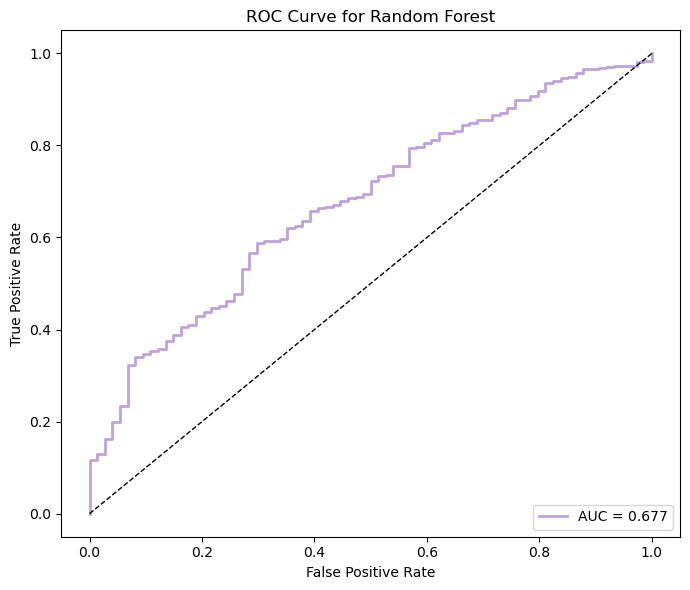

In [84]:
# Compute ROC
fpr, tpr, thresholds = roc_curve(y_val, pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color="#BFA2DB", lw=2, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], "k--", lw=1)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Random Forest")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## Naive Bayes

In [85]:
from sklearn.naive_bayes import GaussianNB

def objective(trial):
    params = {
        "var_smoothing": trial.suggest_loguniform("var_smoothing", 1e-12, 1e-6)
    }

    model = GaussianNB(**params)
    model.fit(X_train, y_train)

    pred_proba = model.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, pred_proba)
    return auc

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=10)

print("Best AUC:", study.best_value)
print("Best Params:", study.best_params)


[I 2026-04-11 20:06:04,982] A new study created in memory with name: no-name-572efb8b-3f28-4784-831c-30cdbefc67ce
C:\Users\Felic\AppData\Local\Temp\ipykernel_55764\762639932.py:5: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  "var_smoothing": trial.suggest_loguniform("var_smoothing", 1e-12, 1e-6)
[I 2026-04-11 20:06:05,154] Trial 0 finished with value: 0.6425633708242404 and parameters: {'var_smoothing': 6.916727075954399e-08}. Best is trial 0 with value: 0.6425633708242404.
C:\Users\Felic\AppData\Local\Temp\ipykernel_55764\762639932.py:5: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  "var_smoothing": trial.suggest_loguniform("var_smoothing", 1e-12, 1e-6)
[I 2026-04-11 

Best AUC: 0.6425633708242404
Best Params: {'var_smoothing': 6.916727075954399e-08}


In [86]:
best_nb_params = study.best_params

nb_model = GaussianNB(
    var_smoothing=best_nb_params["var_smoothing"]
)

nb_model.fit(X_train, y_train)

pred_proba = nb_model.predict_proba(X_val)[:, 1]

thresholds = np.linspace(0.01, 0.99, 200)
balacc = [balanced_accuracy_score(y_val, pred_proba >= t) for t in thresholds]

best_threshold = thresholds[np.argmax(balacc)]

preds_raw = (pred_proba >= best_threshold).astype(int)

In [87]:
nb_roc = roc_auc_score(y_val, pred_proba)
nb_f1 = f1_score(y_val, preds_raw)
nb_accuracy = accuracy_score(y_val, preds_raw)
nb_balanced_acc = balanced_accuracy_score(y_val, preds_raw)

nb_test_results = {
    "Accuracy": nb_accuracy,
    "Balanced Accuracy": nb_balanced_acc,
    "F1 Score": nb_f1,
    "ROC AUC": nb_roc
}

print("Naive Bayes")
print("Best Threshold:", best_threshold)
print("ROC/AUC Score:", nb_roc)
print("F1 Score:", nb_f1)
print("Accuracy:", nb_accuracy)

Naive Bayes
Best Threshold: 0.01
ROC/AUC Score: 0.6425633708242404
F1 Score: 0.5460599334073252
Accuracy: 0.43036211699164345


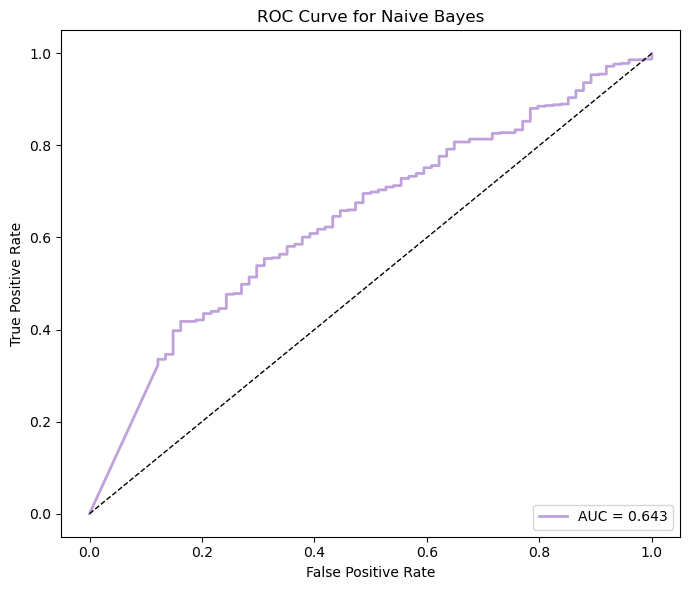

In [88]:
# Compute ROC
fpr, tpr, thresholds = roc_curve(y_val, pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color="#BFA2DB", lw=2, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], "k--", lw=1)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Naive Bayes")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## Stacking

In [89]:
from sklearn.ensemble import StackingClassifier

base_models = [
    ('svm', SVC_model),
    ('dt', dt_model),
    ('rf', rf_model),
    ('xgb', xgb),
    ('nb', nb_model),
    ('nn', nn_model)
]

meta_model = LogisticRegression(max_iter=500)

stacking_model = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    stack_method="predict_proba",
    passthrough=False,              
    n_jobs=-1
)

# Fit
stacking_model.fit(X_train, y_train)

pred_proba = stacking_model.predict_proba(X_val)[:, 1]

thresholds = np.linspace(0.01, 0.99, 200)
balacc = [balanced_accuracy_score(y_val, pred_proba >= t) for t in thresholds]

best_threshold = thresholds[np.argmax(balacc)]

preds_raw = (pred_proba >= best_threshold).astype(int)

stack_test_results = {
    "Accuracy": accuracy_score(y_val, preds_raw),
    "Balanced Accuracy": balanced_accuracy_score(y_val, preds_raw),
    "F1 Score": f1_score(y_val, preds_raw),
    "ROC AUC": roc_auc_score(y_val, pred_proba)
}
# Evaluate
print("Stacking Model:")
print("Best Threshold:", best_threshold)
print("ROC AUC:", roc_auc_score(y_val, pred_proba))
print("Balanced Accuracy:", balanced_accuracy_score(y_val, preds_raw))
print("F1:", f1_score(y_val, preds_raw))
print("Accuracy:", accuracy_score(y_val, preds_raw))


Stacking Model:
Best Threshold: 0.9161306532663317
ROC AUC: 0.6890632868893738
Balanced Accuracy: 0.6477253651166694
F1: 0.6078639744952179
Accuracy: 0.4860724233983287


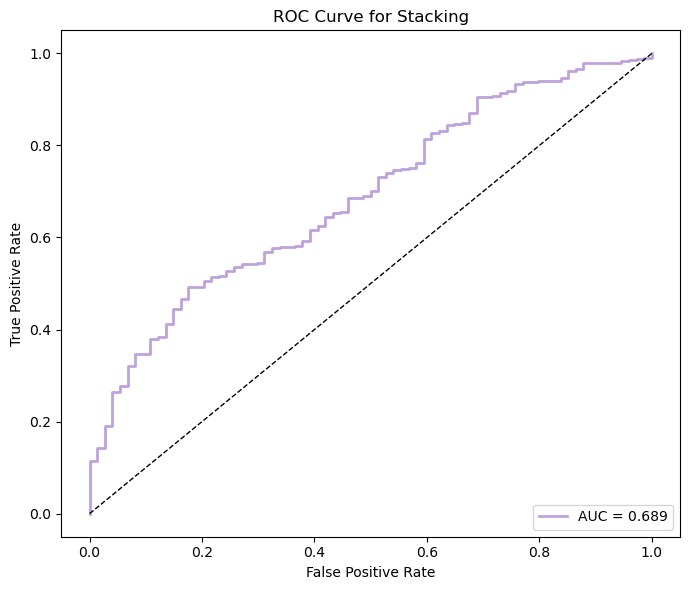

In [90]:
# Compute ROC
fpr, tpr, thresholds = roc_curve(y_val, pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color="#BFA2DB", lw=2, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], "k--", lw=1)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Stacking")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# Evaluation

## Summary of Regression Statistics


In [103]:
all_metrics = pd.DataFrame({
    "SVM": svm_test_results,
    "Neural Network": nn_test_results,
    "Logistic Regression": lr_test_results,
    "XGBoost": xgb_test_results,
    "Decision Tree": dt_test_results,
    "Random Forest": rf_test_results,
    "Naive Bayes": nb_test_results,
    "Stacking": stack_test_results
}).T
all_metrics.sort_values("ROC AUC", ascending = False)

,Accuracy,Balanced Accuracy,F1 Score,ROC AUC
Logistic Regression,0.850975,0.558104,0.917756,0.700940
Stacking,0.486072,0.647725,0.607864,0.689063
Random Forest,0.596100,0.643277,0.721689,0.677333
XGBoost,0.519499,0.630477,0.646878,0.670493
Naive Bayes,0.430362,0.616669,0.546060,0.642563
Neural Network,0.576602,0.590545,0.708253,0.604100
SVM,0.118384,0.508540,0.033588,0.540666
Decision Tree,0.512535,0.536889,0.650699,0.523030


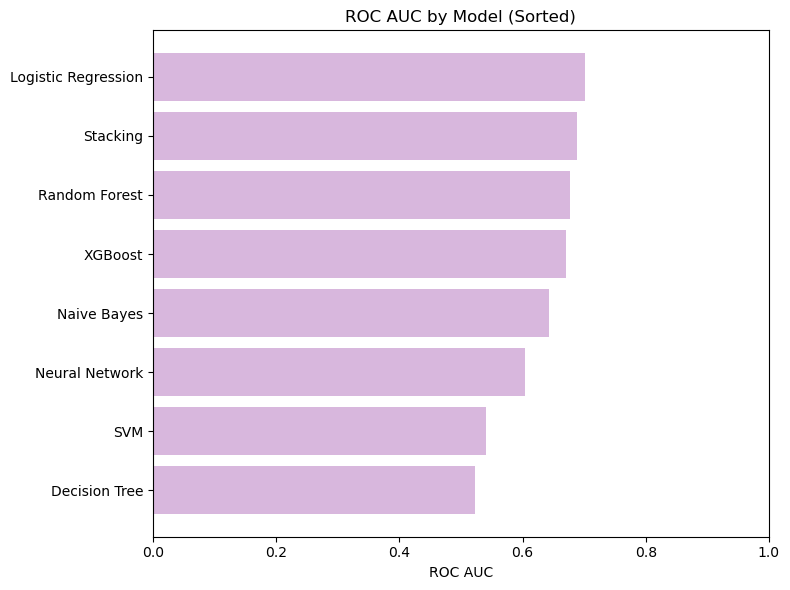

In [102]:
sorted_df = all_metrics.sort_values("ROC AUC", ascending=False)

metric_names = sorted_df.index
metric_values = sorted_df["ROC AUC"].values  # 1D array

plt.figure(figsize=(8, 6))
plt.barh(metric_names, metric_values, color="#D8B7DD")
plt.xlabel("ROC AUC")
plt.title("ROC AUC by Model (Sorted)")
plt.xlim(0, 1)
plt.gca().invert_yaxis()  # highest at top
plt.tight_layout()
plt.show()

In [ ]:
Interpretation: Stacking was the best modek, and unsupervised clustering methods did not work out